(np.float64(-0.5), np.float64(2761.5), np.float64(1039.5), np.float64(-0.5))

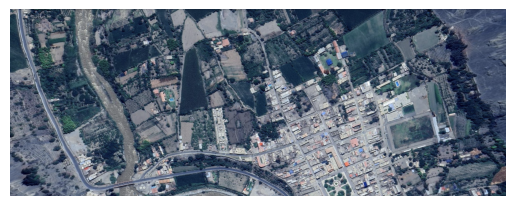

In [1]:
from PIL import Image
import matplotlib.pyplot as plt

# cargar imagen
image = Image.open("imagen.png")

# mostrar imagen
plt.imshow(image)
plt.axis("off")

In [2]:
!git clone https://github.com/facebookresearch/segment-anything.git

fatal: destination path 'segment-anything' already exists and is not an empty directory.


In [3]:
%cd segment-anything

/content/segment-anything


In [4]:
!pip install -q -e .

  Preparing metadata (setup.py) ... done


In [7]:
# Descargar el modelo entrenado
!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

--2026-04-23 20:16:20--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 13.249.182.62, 13.249.182.81, 13.249.182.39, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|13.249.182.62|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 375042383 (358M) [binary/octet-stream]
Saving to: ‘sam_vit_b_01ec64.pth’

sam_vit_b_01ec64.pt 100%[===================>] 357.67M   301MB/s    in 1.2s    

2026-04-23 20:16:22 (301 MB/s) - ‘sam_vit_b_01ec64.pth’ saved [375042383/375042383]



In [8]:
import torch
from segment_anything import sam_model_registry

# definir el tipo de modelo que vamos a usar (vit_h = modelo grande y preciso)
model_type = "vit_b"

# ruta donde se descargó el modelo
sam_checkpoint = "sam_vit_b_01ec64.pth"

# seleccionar dispositivo: GPU si hay, sino CPU
device = "cuda" if torch.cuda.is_available() else "cpu"

# cargar el modelo desde el checkpoint
sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)

# mover el modelo al dispositivo (GPU recomendado)
sam.to(device=device)

Sam(
  (image_encoder): ImageEncoderViT(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (blocks): ModuleList(
      (0-11): 12 x Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): Linear(in_features=3072, out_features=768, bias=True)
          (act): GELU(approximate='none')
        )
      )
    )
    (neck): Sequential(
      (0): Conv2d(768, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): LayerNorm2d()
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (3): LayerNorm2d()
    )


In [9]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from segment_anything import SamAutomaticMaskGenerator

# cargar la imagen con OpenCV
image = cv2.imread("../imagen.png")  # sube un nivel en carpetas

# convertir de BGR (opencv) a RGB (matplotlib)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# crear generador automático de máscaras
mask_generator = SamAutomaticMaskGenerator(sam)

# generar máscaras (aquí ocurre la magia)
masks = mask_generator.generate(image)

# mostrar cantidad de regiones detectadas
print("Número de segmentos detectados:", len(masks))

Número de segmentos detectados: 72


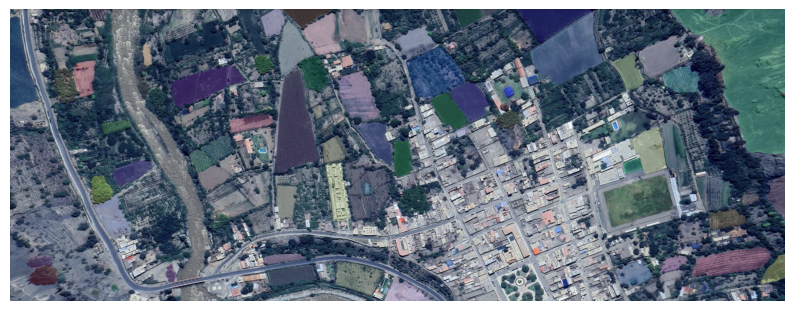

In [10]:
import matplotlib.pyplot as plt
import numpy as np

def show_masks(image, masks):
    plt.figure(figsize=(10, 10))
    plt.imshow(image)

    # ordenar máscaras por tamaño (más grandes primero)
    masks = sorted(masks, key=lambda x: x['area'], reverse=True)

    for mask in masks:
        m = mask['segmentation']

        # color aleatorio
        color = np.random.random(3)

        # crear imagen RGBA (con transparencia controlada)
        overlay = np.zeros((m.shape[0], m.shape[1], 4))
        overlay[:, :, :3] = color  # RGB
        overlay[:, :, 3] = m * 0.2  # alpha bajo para no oscurecer

        plt.imshow(overlay)

    plt.axis('off')

# mostrar resultado
show_masks(image, masks)

(np.float64(-0.5), np.float64(2761.5), np.float64(1039.5), np.float64(-0.5))

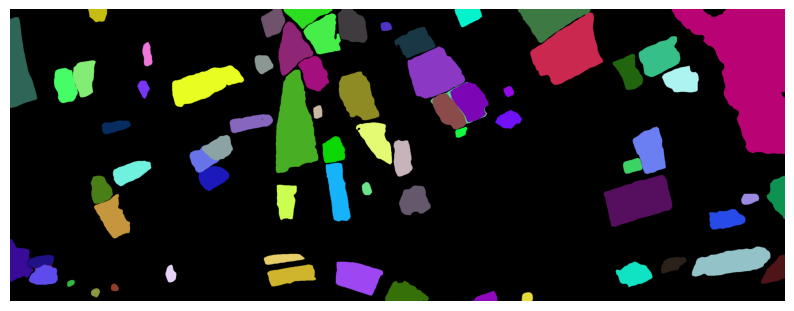

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# crear imagen en blanco
mask_image = np.zeros_like(image)

# recorrer máscaras
for mask in masks:
    m = mask['segmentation']

    # color aleatorio
    color = np.random.randint(0, 255, 3)

    # aplicar color donde hay máscara
    mask_image[m] = color

# mostrar resultado
plt.figure(figsize=(10,10))
plt.imshow(mask_image)
plt.axis("off")